In [3]:
from google.colab import drive
import pandas as pd
from pathlib import Path
import os

# 1. Mount Drive
drive.mount('/content/drive', force_remount=False)

# 2. Define paths
PROJECT_PATH = "/content/drive/MyDrive/dermai-ham10000"
DATA_PATH = f"{PROJECT_PATH}/data"
IMAGES_DIR = Path(f"{DATA_PATH}/images")

# 3. Load metadata (fast - already saved)
meta = pd.read_csv(f"{DATA_PATH}/HAM10000_metadata.csv")

# 4. Quick check
print("✅ Setup complete!")
print(f"Project path: {PROJECT_PATH}")
print(f"Total images in folder: {len(list(IMAGES_DIR.glob('*.jpg')))}")
print(f"Metadata rows: {len(meta)}")

if os.path.exists(f"{DATA_PATH}/train.csv"):
    train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
    val_df   = pd.read_csv(f"{DATA_PATH}/val.csv")
    test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")
    print(f"✅ Splits loaded → Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
else:
    print("⚠️ Splits not found yet")

Mounted at /content/drive
✅ Setup complete!
Project path: /content/drive/MyDrive/dermai-ham10000
Total images in folder: 10015
Metadata rows: 10015
✅ Splits loaded → Train: 7002 | Val: 1532 | Test: 1481


In [4]:
from pathlib import Path

split_files = [
    DATA_PATH + "/train.csv",
    DATA_PATH + "/val.csv",
    DATA_PATH + "/test.csv"
]

for file in split_files:
    path = Path(file)
    print(path, "→", "Exists" if path.exists() else "Missing")

/content/drive/MyDrive/dermai-ham10000/data/train.csv → Exists
/content/drive/MyDrive/dermai-ham10000/data/val.csv → Exists
/content/drive/MyDrive/dermai-ham10000/data/test.csv → Exists


In [5]:
import pandas as pd
from pathlib import Path

meta = pd.read_csv(f"{PROJECT_PATH}/data/HAM10000_metadata.csv")
images_folder = Path(f"{PROJECT_PATH}/data/images")

print("Metadata shape:", meta.shape)
print("\nClass distribution:")
print(meta['dx'].value_counts())
print("\nNumber of image files in folder:", len(list(images_folder.glob("*.jpg"))))
print("\nSample image names:", [f.name for f in list(images_folder.glob("*.jpg"))[:5]])

Metadata shape: (10015, 7)

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Number of image files in folder: 10015

Sample image names: ['ISIC_0033459.jpg', 'ISIC_0033430.jpg', 'ISIC_0033432.jpg', 'ISIC_0033462.jpg', 'ISIC_0033426.jpg']


In [6]:
print(meta.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [7]:
(meta["dx"].value_counts(normalize=True) * 100).round(2)

,proportion
dx,
nv,66.95
mel,11.11
bkl,10.97
bcc,5.13
akiec,3.27
vasc,1.42
df,1.15


/tmp/ipykernel_1886/160064506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x='dx', order=meta['dx'].value_counts().index, palette='viridis')


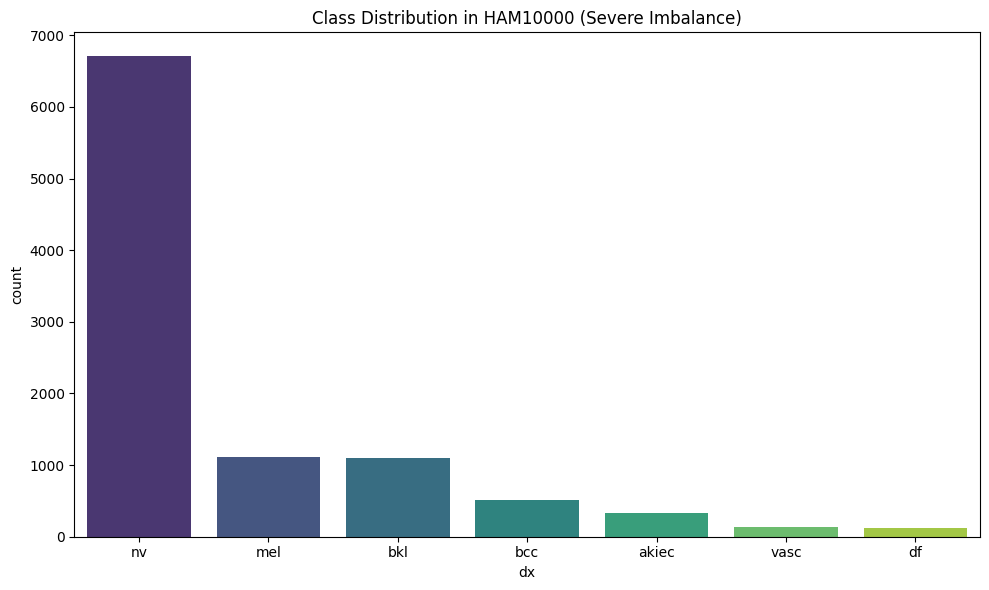

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class distribution (already done, but save the plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=meta, x='dx', order=meta['dx'].value_counts().index, palette='viridis')
plt.title('Class Distribution in HAM10000 (Severe Imbalance)')
plt.xticks()
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/results/class_distribution.png", dpi=150)
plt.show()

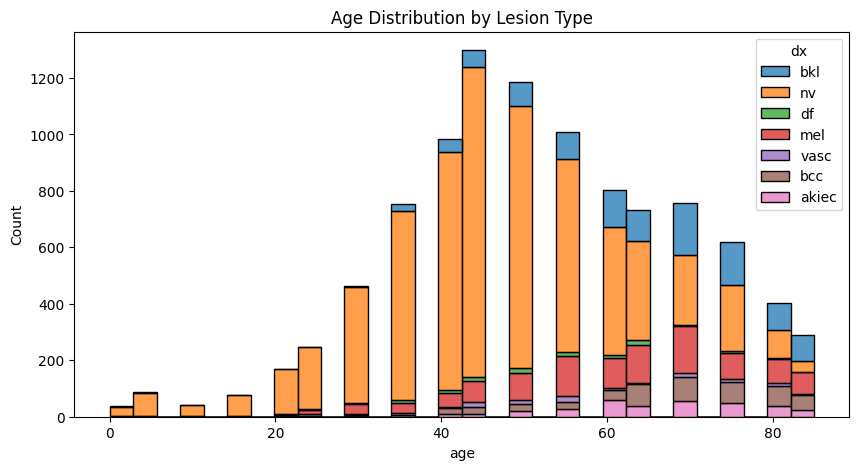

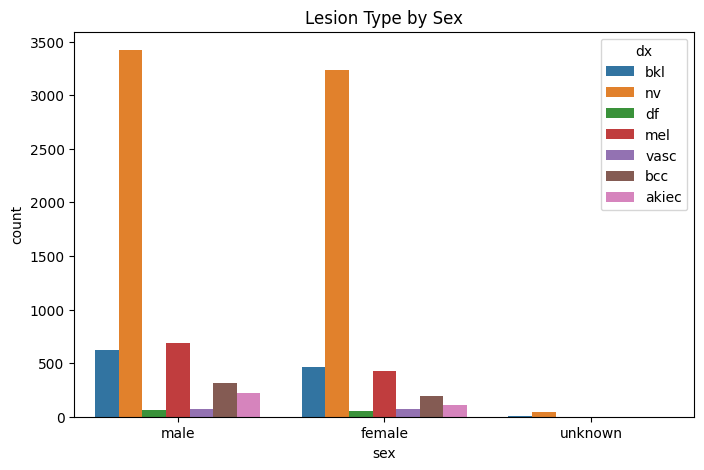

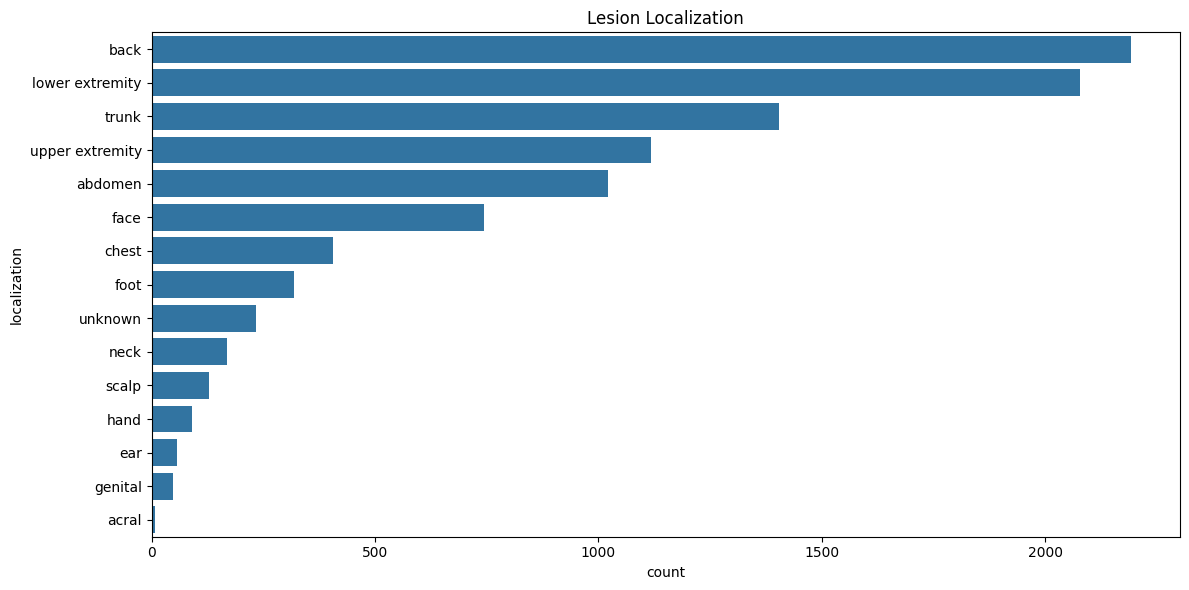

Total unique lesions: 7470
Lesions with more than 1 image: 1956
Max images per lesion: 6


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=meta, x='age', bins=30, hue='dx', multiple='stack')
plt.title('Age Distribution by Lesion Type')
plt.savefig(f"{PROJECT_PATH}/results/age_distribution.png", dpi=150)
plt.show()

# 3. Sex distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=meta, x='sex', hue='dx')
plt.title('Lesion Type by Sex')
plt.savefig(f"{PROJECT_PATH}/results/sex_distribution.png", dpi=150)
plt.show()

# 4. Localization (body part)
plt.figure(figsize=(12, 6))
sns.countplot(data=meta, y='localization', order=meta['localization'].value_counts().index)
plt.title('Lesion Localization')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/results/localization.png", dpi=150)
plt.show()

# 5. How many lesions have multiple images? (Important for splitting)
lesion_counts = meta['lesion_id'].value_counts()
print(f"Total unique lesions: {len(lesion_counts)}")
print(f"Lesions with more than 1 image: {(lesion_counts > 1).sum()}")
print(f"Max images per lesion: {lesion_counts.max()}")


In [10]:
# Impute missing age with median
meta['age'] = meta['age'].fillna(meta['age'].median())

print("Missing age values after imputation:", meta['age'].isnull().sum())

Missing age values after imputation: 0


In [11]:
meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [12]:
meta.describe()

,age
count,10015.000000
mean,51.853220
std,16.920833
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [13]:
meta.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0


In [14]:
meta.groupby('lesion_id')['dx'].nunique().value_counts()

,count
dx,
1,7470


In [15]:
meta[["lesion_id", "dx"]]

,lesion_id,dx
0,HAM_0000118,bkl
1,HAM_0000118,bkl
2,HAM_0002730,bkl
3,HAM_0002730,bkl
4,HAM_0001466,bkl
...,...,...
10010,HAM_0002867,akiec
10011,HAM_0002867,akiec
10012,HAM_0002867,akiec
10013,HAM_0000239,akiec


In [16]:
grouped_lesion = meta[["lesion_id", "dx"]].drop_duplicates()
grouped_lesion.head()

,lesion_id,dx
0,HAM_0000118,bkl
2,HAM_0002730,bkl
4,HAM_0001466,bkl
6,HAM_0002761,bkl
8,HAM_0005132,bkl


In [19]:
from sklearn.model_selection import train_test_split

train_csv = f"{DATA_PATH}/train.csv"
val_csv   = f"{DATA_PATH}/val.csv"
test_csv  = f"{DATA_PATH}/test.csv"

#Load existing split


if os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv):

    train_meta = pd.read_csv(train_csv)
    val_meta   = pd.read_csv(val_csv)
    test_meta  = pd.read_csv(test_csv)

    print("✅ Existing dataset split loaded.")
    print(f"Train: {len(train_meta)}")
    print(f"Val:   {len(val_meta)}")
    print(f"Test:  {len(test_meta)}")


else:

    print("⚠️ No saved split found. Creating split for the first time...")

    grouped_lesion = meta[["lesion_id", "dx"]].drop_duplicates()

    X = grouped_lesion["lesion_id"]
    y = grouped_lesion["dx"]

    # 70% train, 30% temporary
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        stratify=y,
        test_size=0.3,
        random_state=42
    )

    # Split remaining 30% equally that is 15% val, 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        stratify=y_temp,
        test_size=0.5,
        random_state=42
    )

    # Create metadata DataFrames
    train_meta = meta[meta["lesion_id"].isin(X_train)].copy()
    val_meta   = meta[meta["lesion_id"].isin(X_val)].copy()
    test_meta  = meta[meta["lesion_id"].isin(X_test)].copy()

    # Save permanently to Google Drive
    train_meta.to_csv(train_csv, index=False)
    val_meta.to_csv(val_csv, index=False)
    test_meta.to_csv(test_csv, index=False)

    print("✅ New split created and saved to Drive.")
    print(f"Train: {len(train_meta)}")
    print(f"Val:   {len(val_meta)}")
    print(f"Test:  {len(test_meta)}")

✅ Existing dataset split loaded.
Train: 7002
Val:   1532
Test:  1481


In [24]:
train_meta["lesion_id"].isin(val_meta["lesion_id"]).sum()

np.int64(0)

In [25]:
train_meta["lesion_id"].isin(test_meta["lesion_id"]).sum()

np.int64(0)

In [26]:
val_meta["lesion_id"].isin(test_meta["lesion_id"]).sum()

np.int64(0)

In [27]:
PROJECT_PATH = "/content/drive/MyDrive/dermai-ham10000"
IMAGES_DIR = Path(f"{PROJECT_PATH}/data/images")

In [28]:
def make_image_path(image_id):
  return IMAGES_DIR / (image_id +".jpg")


train_meta["image_path"]= train_meta["image_id"].apply(make_image_path)

In [29]:
train_meta[["image_id", "image_path"]].head()

,image_id,image_path
0,ISIC_0026769,/content/drive/MyDrive/dermai-ham10000/data/im...
1,ISIC_0025661,/content/drive/MyDrive/dermai-ham10000/data/im...
2,ISIC_0031633,/content/drive/MyDrive/dermai-ham10000/data/im...
3,ISIC_0027850,/content/drive/MyDrive/dermai-ham10000/data/im...
4,ISIC_0029176,/content/drive/MyDrive/dermai-ham10000/data/im...


In [30]:
#checking all the path exists
train_meta["image_path"].apply(
    lambda path: path.exists()
).value_counts()

,count
image_path,
True,7002


In [31]:
val_meta["image_path"]= val_meta["image_id"].apply(make_image_path)

In [32]:
val_meta["image_path"].apply(
    lambda path: path.exists()
).value_counts()

,count
image_path,
True,1532


In [33]:
test_meta["image_path"]= test_meta["image_id"].apply(make_image_path)
test_meta["image_path"].apply(
    lambda path: path.exists()
).value_counts()

,count
image_path,
True,1481


In [34]:
class_to_idx = {
    "nv": 0,
    "bkl": 1,
    "mel": 2,
    "bcc": 3,
    "akiec": 4,
    "vasc": 5,
    "df": 6
}

In [35]:
train_meta["label"] = train_meta["dx"].map(class_to_idx)

In [36]:
val_meta["label"] = val_meta["dx"].map(class_to_idx)

In [37]:
test_meta["label"] = test_meta["dx"].map(class_to_idx)

In [38]:
train_meta["label"].isna().sum()

np.int64(0)

In [39]:
test_meta["label"].isna().sum()

np.int64(0)

In [40]:
val_meta["label"].isna().sum()

np.int64(0)

In [41]:
from PIL import Image

image_path = train_meta["image_path"].iloc[0]
image = Image.open(image_path)

In [42]:
image.size

(600, 450)

In [43]:
image.mode

'RGB'

In [44]:
import torch
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


In [45]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [46]:
import torch.nn as nn
model.fc = nn.Linear(2048,7)
model.fc

Linear(in_features=2048, out_features=7, bias=True)

In [47]:
weights= models.ResNet50_Weights.DEFAULT
transform = weights.transforms()
transform

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [48]:
type(transform)


torchvision.transforms._presets.ImageClassification

In [49]:
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [50]:
transform.resize_size

[232]

In [51]:
transform.crop_size

[224]

In [52]:
transform.mean

[0.485, 0.456, 0.406]

In [53]:
transform.std

[0.229, 0.224, 0.225]

In [54]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), #ourtrainingaugmentation
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(transform.mean,transform.std),

])

In [55]:
val_transform = weights.transforms()

In [56]:
test_transform = weights.transforms()

In [57]:
from torch.utils.data import Dataset
class SkinLesionClassifier(Dataset):
  def __init__(self, dataframe, transform=None):
      self.dataframe=dataframe
      self.transform=transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, i):
    row = self.dataframe.iloc[i]
    image_path = row["image_path"]
    image = Image.open(image_path)
    image = self.transform(image)
    label = row["label"]
    return image, label


In [58]:
train_dataset = SkinLesionClassifier(
    train_meta,
    train_transform
)

val_dataset = SkinLesionClassifier(
    val_meta,
    val_transform
)

test_dataset = SkinLesionClassifier(
    test_meta,
    test_transform
)

In [59]:
len(train_dataset)

7002

In [60]:
image, label = train_dataset[0]
print(image.shape)
print(label)

torch.Size([3, 224, 224])
1


In [61]:
class_frequency = train_meta["label"].value_counts()
weight = 1/class_frequency
print(weight)

label
0    0.000214
2    0.001285
1    0.001292
3    0.002732
4    0.004348
5    0.010101
6    0.013158
Name: count, dtype: float64


In [62]:
from torch.utils.data import DataLoader, WeightedRandomSampler

sample_weights = torch.tensor(train_meta["label"].map(weight).values, dtype=torch.double)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights) , replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

In [63]:
_, labels = next(iter(train_loader))

In [64]:
torch.bincount(labels) #How many samples of each class are in this batch?

tensor([6, 5, 4, 6, 5, 3, 3])

In [65]:
indices = list(sampler)
sampled_labels = torch.tensor(train_meta.iloc[indices]["label"].values)
torch.bincount(sampled_labels, minlength=7)

tensor([ 957, 1024, 1037,  962, 1037,  988,  997])

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [67]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [68]:
model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [70]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

In [71]:
optimizer.zero_grad()

output = model(images)
loss = criterion(output, labels)
loss.backward()
optimizer.step()

In [72]:
"""num_epochs = 5

for epoch in range(num_epochs):
    loss_batch = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss_batch.append(loss.item())

        loss.backward()
        optimizer.step()
    average_loss = sum(loss_batch) / len(loss_batch)
    print(average_loss)"""

'num_epochs = 5\n\nfor epoch in range(num_epochs):\n    loss_batch = []\n\n    for images, labels in train_loader:\n        images = images.to(device)\n        labels = labels.to(device)\n\n        optimizer.zero_grad()\n\n        output = model(images)\n        loss = criterion(output, labels)\n        loss_batch.append(loss.item())\n\n        loss.backward()\n        optimizer.step()\n    average_loss = sum(loss_batch) / len(loss_batch)\n    print(average_loss)'

In [73]:
"""checkpoint = {
    "epoch": 5,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": average_loss,
}

torch.save(
    checkpoint,
    f"{PROJECT_PATH}/resnet50_ham10000_checkpoint.pth"
)"""

'checkpoint = {\n    "epoch": 5,\n    "model_state_dict": model.state_dict(),\n    "optimizer_state_dict": optimizer.state_dict(),\n    "train_loss": average_loss,\n}\n\ntorch.save(\n    checkpoint,\n    f"{PROJECT_PATH}/resnet50_ham10000_checkpoint.pth"\n)'

In [74]:
checkpoint_path = f"{PROJECT_PATH}/resnet50_ham10000_checkpoint.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]

print("Resumed from epoch:", start_epoch)

Resumed from epoch: 5


**Validation set test**

In [76]:
"""model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    loss_batch = []

    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)
        loss_batch.append(loss.item())

        predictions = torch.argmax(output, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
average_val_loss = sum(loss_batch) / len(loss_batch)

print("Validation accuracy:", accuracy)
print("Validation loss:", average_val_loss)"""

'model.eval()\n\ncorrect = 0\ntotal = 0\n\nall_predictions = []\nall_labels = []\n\nwith torch.no_grad():\n\n    loss_batch = []\n\n    for images, labels in val_loader:\n        images = images.to(device)\n        labels = labels.to(device)\n\n        output = model(images)\n\n        loss = criterion(output, labels)\n        loss_batch.append(loss.item())\n\n        predictions = torch.argmax(output, dim=1)\n\n        correct += (predictions == labels).sum().item()\n        total += labels.size(0)\n\n        all_predictions.extend(predictions.cpu().numpy())\n        all_labels.extend(labels.cpu().numpy())\n\naccuracy = correct / total\naverage_val_loss = sum(loss_batch) / len(loss_batch)\n\nprint("Validation accuracy:", accuracy)\nprint("Validation loss:", average_val_loss)'

In [77]:
#len(all_predictions)

In [78]:
#len(all_labels)

In [79]:
"""from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
classification_r =classification_report(
    all_labels,
    all_predictions,
    target_names=class_to_idx.keys()
)
print(classification_r)"""

'from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report\nclassification_r =classification_report(\n    all_labels,\n    all_predictions,\n    target_names=class_to_idx.keys()\n)\nprint(classification_r)'

In [80]:
"""from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(all_labels, all_predictions)
print(conf_matrix)"""

'from sklearn.metrics import confusion_matrix\nconf_matrix = confusion_matrix(all_labels, all_predictions)\nprint(conf_matrix)'

In [81]:
"""validation_results = {
    "image_ids": val_meta["image_id"].tolist(),
    "all_labels": all_labels,
    "all_predictions": all_predictions,
    "accuracy": accuracy,
    "val_loss": average_val_loss
}

torch.save(
    validation_results,
    f"{PROJECT_PATH}/resnet50_ham10000_validation.pth"
)"""

'validation_results = {\n    "image_ids": val_meta["image_id"].tolist(),\n    "all_labels": all_labels,\n    "all_predictions": all_predictions,\n    "accuracy": accuracy,\n    "val_loss": average_val_loss\n}\n\ntorch.save(\n    validation_results,\n    f"{PROJECT_PATH}/resnet50_ham10000_validation.pth"\n)'

In [82]:
validation_results = torch.load(
    f"{PROJECT_PATH}/resnet50_ham10000_validation.pth",
    weights_only=False
)

image_ids = validation_results["image_ids"]
all_labels = validation_results["all_labels"]
all_predictions = validation_results["all_predictions"]
accuracy = validation_results["accuracy"]
average_val_loss = validation_results["val_loss"]

**Classification Report**

Note: EDA in this section was performed on an earlier baseline run with identical architecture/hyperparameters to baseline_model below; loss history wasn't captured in that run, so training was repeated to log it.

In [83]:
target_names = [
    "nv",
    "bkl",
    "mel",
    "bcc",
    "akiec",
    "vasc",
    "df"
]

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=target_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

          nv     0.9891    0.8751    0.9286      1033
         bkl     0.8639    0.9429    0.9016       175
         mel     0.5932    0.9398    0.7273       166
         bcc     0.8276    0.9600    0.8889        75
       akiec     0.9535    0.8367    0.8913        49
        vasc     0.8947    0.9444    0.9189        18
          df     0.8421    0.8000    0.8205        20

    accuracy                         0.8926      1536
   macro avg     0.8520    0.8998    0.8682      1536
weighted avg     0.9200    0.8926    0.8991      1536



In [84]:
val_meta_saved = (
    meta.set_index("image_id")
    .loc[image_ids]
    .reset_index()
)

print(len(val_meta_saved))
print(val_meta_saved.head())

1536
       image_id    lesion_id   dx dx_type   age     sex localization
0  ISIC_0026769  HAM_0002730  bkl   histo  80.0    male        scalp
1  ISIC_0025661  HAM_0002730  bkl   histo  80.0    male        scalp
2  ISIC_0029396  HAM_0004234  bkl   histo  85.0  female        chest
3  ISIC_0025984  HAM_0004234  bkl   histo  85.0  female        chest
4  ISIC_0025767  HAM_0001949  bkl   histo  70.0    male        trunk


In [85]:
print("Image IDs:", len(image_ids))
print("Labels:", len(all_labels))
print("Predictions:", len(all_predictions))

Image IDs: 1536
Labels: 1536
Predictions: 1536


In [86]:
nv_mel_indices = [
    i for i in range(len(all_labels))
    if all_labels[i] == 0 and all_predictions[i] == 2
]

print("NV predicted as melanoma:", len(nv_mel_indices))

NV predicted as melanoma: 99


In [87]:
nv_mel_samples = val_meta_saved.iloc[nv_mel_indices]

print(nv_mel_samples.head())

          image_id    lesion_id  dx    dx_type   age     sex     localization
839   ISIC_0028883  HAM_0003372  nv  follow_up  45.0  female            trunk
1027  ISIC_0028332  HAM_0006197  nv      histo  40.0    male             back
1028  ISIC_0032334  HAM_0006197  nv      histo  40.0    male             back
1033  ISIC_0026887  HAM_0005162  nv      histo  50.0  female             back
1044  ISIC_0024824  HAM_0005188  nv      histo  50.0  female  upper extremity


**Investigating why model confuses nv and mel classes**

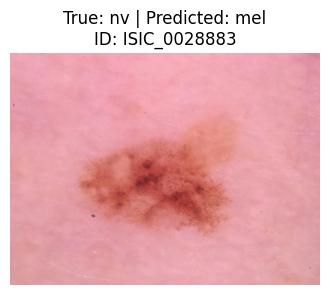

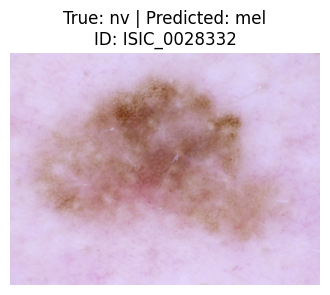

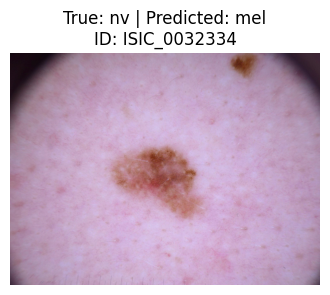

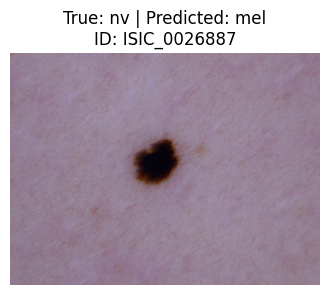

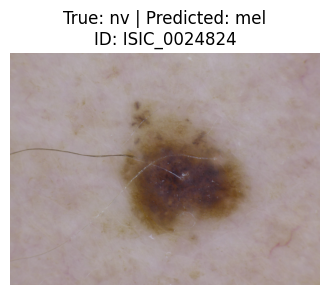

In [88]:
import matplotlib.pyplot as plt
from PIL import Image

for _, row in nv_mel_samples.head(5).iterrows():

    image_path = IMAGES_DIR / f"{row['image_id']}.jpg"
    image = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(
        f"True: {row['dx']} | Predicted: mel\n"
        f"ID: {row['image_id']}"
    )
    plt.axis("off")
    plt.show()

In [89]:
nv_mel_samples["dx_type"].value_counts()

,count
dx_type,
histo,84
consensus,14
follow_up,1


In [90]:
val_meta_saved[val_meta_saved["dx"] == "nv"]["dx_type"].value_counts()

,count
dx_type,
follow_up,550
histo,400
consensus,83


In [91]:
# Histo false-positive rate
histo_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["dx_type"] == "histo"])
    /
    len(val_meta_saved[
        (val_meta_saved["dx"] == "nv") &
        (val_meta_saved["dx_type"] == "histo")
    ])
)

# Consensus false-positive rate
consensus_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["dx_type"] == "consensus"])
    /
    len(val_meta_saved[
        (val_meta_saved["dx"] == "nv") &
        (val_meta_saved["dx_type"] == "consensus")
    ])
)

# Follow-up false-positive rate
followup_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["dx_type"] == "follow_up"])
    /
    len(val_meta_saved[
        (val_meta_saved["dx"] == "nv") &
        (val_meta_saved["dx_type"] == "follow_up")
    ])
)

print("Histo:", histo_fp_rate)
print("Consensus:", consensus_fp_rate)
print("Follow-up:", followup_fp_rate)

Histo: 0.21
Consensus: 0.1686746987951807
Follow-up: 0.0018181818181818182


In [92]:
nv_mel_samples["localization"].value_counts()

,count
localization,
back,35
chest,14
upper extremity,12
trunk,11
abdomen,10
foot,7
unknown,5
lower extremity,4
ear,1


In [93]:
back_localization_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["localization"] == "back"])/
    len(val_meta_saved[(val_meta_saved["dx"] == "nv") & (val_meta_saved["localization"] == "back")]))
print(back_localization_fp_rate)

0.1724137931034483


In [94]:
bins = [0, 30, 40, 50, 60, 70, float("inf")]

labels = [
    "<30",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]
val_meta_saved["age_group"] = pd.cut(
    val_meta_saved["age"],
    bins=bins,
    labels=labels,
    right=False
)
nv_mel_samples["age_group"] = pd.cut(
    nv_mel_samples["age"],
    bins=bins,
    labels=labels,
    right=False
)

/tmp/ipykernel_1886/1977154554.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nv_mel_samples["age_group"] = pd.cut(


In [95]:
nv_mel_samples["age_group"].value_counts().sort_index()

,count
age_group,
<30,12
30-39,14
40-49,16
50-59,13
60-69,12
70+,32


In [96]:
val_meta_saved[val_meta_saved["dx"] == "nv"]["age_group"].value_counts().sort_index()

,count
age_group,
<30,81
30-39,175
40-49,304
50-59,253
60-69,112
70+,108


In [97]:
fp_counts = (
    nv_mel_samples["age_group"]
    .value_counts()
    .sort_index()
)

nv_counts = (
    val_meta_saved[val_meta_saved["dx"] == "nv"]["age_group"]
    .value_counts()
    .sort_index()
)

age_fp_rate = fp_counts / nv_counts

print(age_fp_rate)

age_group
<30      0.148148
30-39    0.080000
40-49    0.052632
50-59    0.051383
60-69    0.107143
70+      0.296296
Name: count, dtype: float64


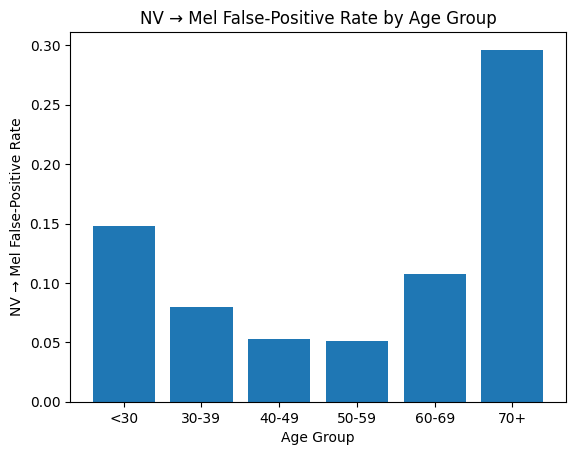

In [98]:
import matplotlib.pyplot as plt

plt.bar(age_fp_rate.index, age_fp_rate.values)

plt.xlabel("Age Group")
plt.ylabel("NV → Mel False-Positive Rate")
plt.title("NV → Mel False-Positive Rate by Age Group")

plt.show()

In [99]:
nv_mel_samples["sex"].value_counts()

,count
sex,
male,61
female,38


In [100]:
male_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["sex"] == "male"])/
    len(val_meta_saved[(val_meta_saved["dx"] == "nv") & (val_meta_saved["sex"] == "male")]))
print(male_fp_rate)

female_fp_rate = (
    len(nv_mel_samples[nv_mel_samples["sex"] == "female"])/
    len(val_meta_saved[(val_meta_saved["dx"] == "nv") & (val_meta_saved["sex"] == "female")]))
print(female_fp_rate)

0.11937377690802348
0.07407407407407407


In [101]:
from torchvision import models
import torch.nn as nn

baseline_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

baseline_model.fc = nn.Linear(2048, 7)

baseline_model = baseline_model.to(device)

In [102]:
baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=1e-4
)

In [103]:
"""num_epochs = 5

train_loss_history = []

for epoch in range(num_epochs):

    baseline_model.train()

    loss_batch = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        baseline_optimizer.zero_grad()

        output = baseline_model(images)

        loss = baseline_criterion(output, labels)

        loss.backward()
        baseline_optimizer.step()

        loss_batch.append(loss.item())

    average_train_loss = sum(loss_batch) / len(loss_batch)

    train_loss_history.append(average_train_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {average_train_loss:.4f}"
    )"""

'num_epochs = 5\n\ntrain_loss_history = []\n\nfor epoch in range(num_epochs):\n\n    baseline_model.train()\n\n    loss_batch = []\n\n    for images, labels in train_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        baseline_optimizer.zero_grad()\n\n        output = baseline_model(images)\n\n        loss = baseline_criterion(output, labels)\n\n        loss.backward()\n        baseline_optimizer.step()\n\n        loss_batch.append(loss.item())\n\n    average_train_loss = sum(loss_batch) / len(loss_batch)\n\n    train_loss_history.append(average_train_loss)\n\n    print(\n        f"Epoch {epoch + 1}/{num_epochs} "\n        f"- Train Loss: {average_train_loss:.4f}"\n    )'

In [113]:
#NEW BASELINE CHECKPOINT
"""baseline_checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": baseline_model.state_dict(),
    "optimizer_state_dict": baseline_optimizer.state_dict(),
    "train_loss_history": train_loss_history,
}

baseline_checkpoint_path = (
    f"{PROJECT_PATH}/resnet50_ham10000_baseline_v2.pth"
)

torch.save(
    baseline_checkpoint,
    baseline_checkpoint_path
)

print(f"✅ Checkpoint saved to:")
print(baseline_checkpoint_path)"""

'baseline_checkpoint = {\n    "epoch": num_epochs,\n    "model_state_dict": baseline_model.state_dict(),\n    "optimizer_state_dict": baseline_optimizer.state_dict(),\n    "train_loss_history": train_loss_history,\n}\n\nbaseline_checkpoint_path = (\n    f"{PROJECT_PATH}/resnet50_ham10000_baseline_v2.pth"\n)\n\ntorch.save(\n    baseline_checkpoint,\n    baseline_checkpoint_path\n)\n\nprint(f"✅ Checkpoint saved to:")\nprint(baseline_checkpoint_path)'

In [105]:
"""baseline_model.eval()

all_predictions = []
all_labels = []
val_loss_batch = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        output = baseline_model(images)

        loss = baseline_criterion(output, labels)
        val_loss_batch.append(loss.item())

        predictions = torch.argmax(output, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


average_val_loss = sum(val_loss_batch) / len(val_loss_batch)

accuracy = (
    sum(p == y for p, y in zip(all_predictions, all_labels))
    / len(all_labels)
)

from sklearn.metrics import f1_score

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print("Validation loss:", average_val_loss)
print("Validation accuracy:", accuracy)
print("Validation macro F1:", macro_f1)"""

'baseline_model.eval()\n\nall_predictions = []\nall_labels = []\nval_loss_batch = []\n\nwith torch.no_grad():\n\n    for images, labels in val_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        output = baseline_model(images)\n\n        loss = baseline_criterion(output, labels)\n        val_loss_batch.append(loss.item())\n\n        predictions = torch.argmax(output, dim=1)\n\n        all_predictions.extend(predictions.cpu().numpy())\n        all_labels.extend(labels.cpu().numpy())\n\n\naverage_val_loss = sum(val_loss_batch) / len(val_loss_batch)\n\naccuracy = (\n    sum(p == y for p, y in zip(all_predictions, all_labels))\n    / len(all_labels)\n)\n\nfrom sklearn.metrics import f1_score\n\nmacro_f1 = f1_score(\n    all_labels,\n    all_predictions,\n    average="macro"\n)\n\nprint("Validation loss:", average_val_loss)\nprint("Validation accuracy:", accuracy)\nprint("Validation macro F1:", macro_f1)'

In [106]:
"""baseline_validation_results = {
    "image_ids": val_meta["image_id"].tolist(),
    "all_labels": all_labels,
    "all_predictions": all_predictions,
    "accuracy": accuracy,
    "val_loss": average_val_loss,
    "macro_f1": macro_f1,
}

baseline_validation_path = (
    f"{PROJECT_PATH}/resnet50_ham10000_baseline_v2_validation.pth"
)

torch.save(
    baseline_validation_results,
    baseline_validation_path
)

print(f"✅ Validation results saved to:")
print(baseline_validation_path)"""

'baseline_validation_results = {\n    "image_ids": val_meta["image_id"].tolist(),\n    "all_labels": all_labels,\n    "all_predictions": all_predictions,\n    "accuracy": accuracy,\n    "val_loss": average_val_loss,\n    "macro_f1": macro_f1,\n}\n\nbaseline_validation_path = (\n    f"{PROJECT_PATH}/resnet50_ham10000_baseline_v2_validation.pth"\n)\n\ntorch.save(\n    baseline_validation_results,\n    baseline_validation_path\n)\n\nprint(f"✅ Validation results saved to:")\nprint(baseline_validation_path)'

In [107]:
experiment2_results = torch.load(
    f"{PROJECT_PATH}/resnet50_ham10000_baseline_v2_validation.pth",
    weights_only=False
)

In [108]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

          nv       0.99      0.88      0.93      1033
         bkl       0.86      0.94      0.90       175
         mel       0.59      0.94      0.73       166
         bcc       0.83      0.96      0.89        75
       akiec       0.95      0.84      0.89        49
        vasc       0.89      0.94      0.92        18
          df       0.84      0.80      0.82        20

    accuracy                           0.89      1536
   macro avg       0.85      0.90      0.87      1536
weighted avg       0.92      0.89      0.90      1536



In [109]:
print("val_meta:", len(val_meta))
print("val_dataset:", len(val_dataset))
print("val_loader batches:", len(val_loader))
print("predictions:", len(all_predictions))
print("labels:", len(all_labels))

val_meta: 1532
val_dataset: 1532
val_loader batches: 48
predictions: 1536
labels: 1536


In [110]:
from sklearn.metrics import confusion_matrix
baseline_model_cf = confusion_matrix(all_labels, all_predictions)
print(baseline_model_cf)

[[904  18  99   7   0   2   3]
 [  2 165   5   3   0   0   0]
 [  6   2 156   1   1   0   0]
 [  0   2   1  72   0   0   0]
 [  2   4   1   1  41   0   0]
 [  0   0   0   1   0  17   0]
 [  0   0   1   2   1   0  16]]


In [111]:
from torchvision import transforms

experiment_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        transform.mean,
        transform.std
    )
])

In [112]:
experiment_train_dataset = SkinLesionClassifier(
    train_meta,
    experiment_train_transform
)

In [114]:
experiment_train_loader = DataLoader(
    experiment_train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

In [115]:
from torchvision import models
import torch.nn as nn

augmentation_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

augmentation_model.fc = nn.Linear(2048, 7)

augmentation_model = augmentation_model.to(device)

augmentation_criterion = nn.CrossEntropyLoss()

augmentation_optimizer = torch.optim.AdamW(
    augmentation_model.parameters(),
    lr=1e-4
)

In [116]:
"""num_epochs = 5

augmentation_train_loss_history = []

for epoch in range(num_epochs):

    augmentation_model.train()

    loss_batch = []

    for images, labels in experiment_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        augmentation_optimizer.zero_grad()

        output = augmentation_model(images)

        loss = augmentation_criterion(output, labels)

        loss.backward()
        augmentation_optimizer.step()

        loss_batch.append(loss.item())

    average_train_loss = sum(loss_batch) / len(loss_batch)

    augmentation_train_loss_history.append(average_train_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {average_train_loss:.4f}"
    )"""

'num_epochs = 5\n\naugmentation_train_loss_history = []\n\nfor epoch in range(num_epochs):\n\n    augmentation_model.train()\n\n    loss_batch = []\n\n    for images, labels in experiment_train_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        augmentation_optimizer.zero_grad()\n\n        output = augmentation_model(images)\n\n        loss = augmentation_criterion(output, labels)\n\n        loss.backward()\n        augmentation_optimizer.step()\n\n        loss_batch.append(loss.item())\n\n    average_train_loss = sum(loss_batch) / len(loss_batch)\n\n    augmentation_train_loss_history.append(average_train_loss)\n\n    print(\n        f"Epoch {epoch + 1}/{num_epochs} "\n        f"- Train Loss: {average_train_loss:.4f}"\n    )'

In [117]:
"""augmentation_checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": augmentation_model.state_dict(),
    "optimizer_state_dict": augmentation_optimizer.state_dict(),
    "train_loss_history": augmentation_train_loss_history,
}

augmentation_checkpoint_path = (
    f"{PROJECT_PATH}/resnet50_ham10000_experiment1_augmentation.pth"
)

torch.save(
    augmentation_checkpoint,
    augmentation_checkpoint_path
)

print(f"✅ Experiment 1 checkpoint saved to:")
print(augmentation_checkpoint_path)"""

'augmentation_checkpoint = {\n    "epoch": num_epochs,\n    "model_state_dict": augmentation_model.state_dict(),\n    "optimizer_state_dict": augmentation_optimizer.state_dict(),\n    "train_loss_history": augmentation_train_loss_history,\n}\n\naugmentation_checkpoint_path = (\n    f"{PROJECT_PATH}/resnet50_ham10000_experiment1_augmentation.pth"\n)\n\ntorch.save(\n    augmentation_checkpoint,\n    augmentation_checkpoint_path\n)\n\nprint(f"✅ Experiment 1 checkpoint saved to:")\nprint(augmentation_checkpoint_path)'

In [118]:
"""augmentation_model.eval()

augmentation_val_loss_batch = []

augmentation_all_labels = []
augmentation_all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        output = augmentation_model(images)

        loss = augmentation_criterion(output, labels)
        augmentation_val_loss_batch.append(loss.item())

        predictions = torch.argmax(output, dim=1)

        augmentation_all_labels.extend(
            labels.cpu().numpy()
        )

        augmentation_all_predictions.extend(
            predictions.cpu().numpy()
        )


augmentation_val_loss = (
    sum(augmentation_val_loss_batch)
    / len(augmentation_val_loss_batch)
)

augmentation_accuracy = (
    sum(
        p == y
        for p, y in zip(
            augmentation_all_predictions,
            augmentation_all_labels
        )
    )
    / len(augmentation_all_labels)
)

from sklearn.metrics import f1_score

augmentation_macro_f1 = f1_score(
    augmentation_all_labels,
    augmentation_all_predictions,
    average="macro"
)

print("Experiment 1 validation loss:", augmentation_val_loss)
print("Experiment 1 validation accuracy:", augmentation_accuracy)
print("Experiment 1 validation macro F1:", augmentation_macro_f1)"""

'augmentation_model.eval()\n\naugmentation_val_loss_batch = []\n\naugmentation_all_labels = []\naugmentation_all_predictions = []\n\nwith torch.no_grad():\n\n    for images, labels in val_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        output = augmentation_model(images)\n\n        loss = augmentation_criterion(output, labels)\n        augmentation_val_loss_batch.append(loss.item())\n\n        predictions = torch.argmax(output, dim=1)\n\n        augmentation_all_labels.extend(\n            labels.cpu().numpy()\n        )\n\n        augmentation_all_predictions.extend(\n            predictions.cpu().numpy()\n        )\n\n\naugmentation_val_loss = (\n    sum(augmentation_val_loss_batch)\n    / len(augmentation_val_loss_batch)\n)\n\naugmentation_accuracy = (\n    sum(\n        p == y\n        for p, y in zip(\n            augmentation_all_predictions,\n            augmentation_all_labels\n        )\n    )\n    / len(augmentation_all_labels)\n)\

In [119]:
"""experiment1_validation_results = {
    "image_ids": val_meta["image_id"].tolist(),
    "augmentation_all_labels": augmentation_all_labels,
    "augmentation_all_predictions": augmentation_all_predictions,
    "augmentation_accuracy": augmentation_accuracy,
    "augmentation_val_loss": augmentation_val_loss,
    "augmentation_macro_f1": augmentation_macro_f1,
}

torch.save(
    experiment1_validation_results,
    f"{PROJECT_PATH}/resnet50_ham10000_augmentation_validation.pth"
)

print("✅ Augmentation validation results saved.")"""

'experiment1_validation_results = {\n    "image_ids": val_meta["image_id"].tolist(),\n    "augmentation_all_labels": augmentation_all_labels,\n    "augmentation_all_predictions": augmentation_all_predictions,\n    "augmentation_accuracy": augmentation_accuracy,\n    "augmentation_val_loss": augmentation_val_loss,\n    "augmentation_macro_f1": augmentation_macro_f1,\n}\n\ntorch.save(\n    experiment1_validation_results,\n    f"{PROJECT_PATH}/resnet50_ham10000_augmentation_validation.pth"\n)\n\nprint("✅ Augmentation validation results saved.")'

In [142]:
experiment2_results = torch.load(
    f"{PROJECT_PATH}/resnet50_ham10000_augmentation_validation.pth",
    weights_only=False
)
augmentation_all_labels = experiment2_results["augmentation_all_labels"]
augmentation_all_predictions= experiment2_results["augmentation_all_predictions"]



In [143]:
from sklearn.metrics import classification_report

print(
    classification_report(
        augmentation_all_labels,
        augmentation_all_predictions,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

          nv       0.95      0.83      0.88      1034
         bkl       0.66      0.67      0.67       157
         mel       0.44      0.67      0.53       170
         bcc       0.58      0.79      0.67        77
       akiec       0.51      0.69      0.59        51
        vasc       0.64      0.88      0.74        24
          df       0.75      0.32      0.44        19

    accuracy                           0.78      1532
   macro avg       0.65      0.69      0.65      1532
weighted avg       0.82      0.78      0.79      1532



In [144]:
from sklearn.metrics import confusion_matrix

augmentation_cm = confusion_matrix(
    augmentation_all_labels,
    augmentation_all_predictions
)

print(augmentation_cm)

[[854  33 111  21   7   8   0]
 [  6 105  28   8   9   1   0]
 [ 31  10 114   6   9   0   0]
 [  4   3   0  61   4   3   2]
 [  3   4   1   8  35   0   0]
 [  1   0   2   0   0  21   0]
 [  3   3   2   1   4   0   6]]


Changing the class-balancing strategy.

The combination of stronger augmentation + aggressive minority oversampling may be making the classifier too sensitive to minority classes, including melanoma.

In [146]:
#let's check if removing aggressive oversampling reduce the NV to mel false positives while preserving some of the improvement in melanoma recall?

from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn

experiment2_train_loader = DataLoader(
    experiment_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

experiment2_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

experiment2_model.fc = nn.Linear(2048, 7)

experiment2_model = experiment2_model.to(device)

experiment2_criterion = nn.CrossEntropyLoss()

experiment2_optimizer = torch.optim.AdamW(
    experiment2_model.parameters(),
    lr=1e-4
)



In [145]:
"""num_epochs = 5

experiment2_train_loss_history = []

for epoch in range(num_epochs):

    experiment2_model.train()

    loss_batch = []

    for images, labels in experiment2_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        experiment2_optimizer.zero_grad()

        output = experiment2_model(images)

        loss = experiment2_criterion(output, labels)

        loss.backward()
        experiment2_optimizer.step()

        loss_batch.append(loss.item())

    average_train_loss = (
        sum(loss_batch) / len(loss_batch)
    )

    experiment2_train_loss_history.append(
        average_train_loss
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {average_train_loss:.4f}"
    )"""

'num_epochs = 5\n\nexperiment2_train_loss_history = []\n\nfor epoch in range(num_epochs):\n\n    experiment2_model.train()\n\n    loss_batch = []\n\n    for images, labels in experiment2_train_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        experiment2_optimizer.zero_grad()\n\n        output = experiment2_model(images)\n\n        loss = experiment2_criterion(output, labels)\n\n        loss.backward()\n        experiment2_optimizer.step()\n\n        loss_batch.append(loss.item())\n\n    average_train_loss = (\n        sum(loss_batch) / len(loss_batch)\n    )\n\n    experiment2_train_loss_history.append(\n        average_train_loss\n    )\n\n    print(\n        f"Epoch {epoch + 1}/{num_epochs} "\n        f"- Train Loss: {average_train_loss:.4f}"\n    )'

In [147]:
"""experiment2_checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": experiment2_model.state_dict(),
    "optimizer_state_dict": experiment2_optimizer.state_dict(),
    "train_loss_history": experiment2_train_loss_history,
}

experiment2_checkpoint_path = (
    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler.pth"
)

torch.save(
    experiment2_checkpoint,
    experiment2_checkpoint_path
)

print(
    f"✅ Experiment 2 checkpoint saved to:\n"
    f"{experiment2_checkpoint_path}"
)"""

'experiment2_checkpoint = {\n    "epoch": num_epochs,\n    "model_state_dict": experiment2_model.state_dict(),\n    "optimizer_state_dict": experiment2_optimizer.state_dict(),\n    "train_loss_history": experiment2_train_loss_history,\n}\n\nexperiment2_checkpoint_path = (\n    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler.pth"\n)\n\ntorch.save(\n    experiment2_checkpoint,\n    experiment2_checkpoint_path\n)\n\nprint(\n    f"✅ Experiment 2 checkpoint saved to:\n"\n    f"{experiment2_checkpoint_path}"\n)'

In [148]:
"""experiment2_model.eval()

experiment2_val_loss_batch = []

experiment2_all_labels = []
experiment2_all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        output = experiment2_model(images)

        loss = experiment2_criterion(output, labels)
        experiment2_val_loss_batch.append(loss.item())

        predictions = torch.argmax(output, dim=1)

        experiment2_all_labels.extend(
            labels.cpu().numpy()
        )

        experiment2_all_predictions.extend(
            predictions.cpu().numpy()
        )


experiment2_val_loss = (
    sum(experiment2_val_loss_batch)
    / len(experiment2_val_loss_batch)
)

experiment2_accuracy = (
    sum(
        p == y
        for p, y in zip(
            experiment2_all_predictions,
            experiment2_all_labels
        )
    )
    / len(experiment2_all_labels)
)

from sklearn.metrics import f1_score

experiment2_macro_f1 = f1_score(
    experiment2_all_labels,
    experiment2_all_predictions,
    average="macro"
)

print("Experiment 2 validation loss:", experiment2_val_loss)
print("Experiment 2 validation accuracy:", experiment2_accuracy)
print("Experiment 2 validation macro F1:", experiment2_macro_f1)"""

'experiment2_model.eval()\n\nexperiment2_val_loss_batch = []\n\nexperiment2_all_labels = []\nexperiment2_all_predictions = []\n\nwith torch.no_grad():\n\n    for images, labels in val_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        output = experiment2_model(images)\n\n        loss = experiment2_criterion(output, labels)\n        experiment2_val_loss_batch.append(loss.item())\n\n        predictions = torch.argmax(output, dim=1)\n\n        experiment2_all_labels.extend(\n            labels.cpu().numpy()\n        )\n\n        experiment2_all_predictions.extend(\n            predictions.cpu().numpy()\n        )\n\n\nexperiment2_val_loss = (\n    sum(experiment2_val_loss_batch)\n    / len(experiment2_val_loss_batch)\n)\n\nexperiment2_accuracy = (\n    sum(\n        p == y\n        for p, y in zip(\n            experiment2_all_predictions,\n            experiment2_all_labels\n        )\n    )\n    / len(experiment2_all_labels)\n)\n\nfrom sklearn.

In [149]:
"""experiment2_validation_results = {
    "image_ids": val_meta["image_id"].tolist(),
    "experiment2_all_labels": experiment2_all_labels,
    "experiment2_all_predictions": experiment2_all_predictions,
    "experiment2_accuracy": experiment2_accuracy,
    "experiment2_val_loss": experiment2_val_loss,
    "experiment2_macro_f1": experiment2_macro_f1,
}

torch.save(
    experiment2_validation_results,
    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler_validation.pth"
)

print("✅ Experiment 2 validation results saved.")"""

'experiment2_validation_results = {\n    "image_ids": val_meta["image_id"].tolist(),\n    "experiment2_all_labels": experiment2_all_labels,\n    "experiment2_all_predictions": experiment2_all_predictions,\n    "experiment2_accuracy": experiment2_accuracy,\n    "experiment2_val_loss": experiment2_val_loss,\n    "experiment2_macro_f1": experiment2_macro_f1,\n}\n\ntorch.save(\n    experiment2_validation_results,\n    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler_validation.pth"\n)\n\nprint("✅ Experiment 2 validation results saved.")'

In [129]:
experiment2_results = torch.load(
    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler_validation.pth",
    weights_only=False
)

experiment2_all_labels = experiment2_results["experiment2_all_labels"]
experiment2_all_predictions= experiment2_results["experiment2_all_predictions"]

In [130]:
from sklearn.metrics import classification_report

print(
    classification_report(
        experiment2_all_labels,
        experiment2_all_predictions,
        target_names=target_names
    )
)



              precision    recall  f1-score   support

          nv       0.92      0.90      0.91      1034
         bkl       0.73      0.66      0.70       157
         mel       0.54      0.57      0.55       170
         bcc       0.62      0.82      0.71        77
       akiec       0.56      0.65      0.60        51
        vasc       0.90      0.75      0.82        24
          df       0.44      0.42      0.43        19

    accuracy                           0.82      1532
   macro avg       0.67      0.68      0.67      1532
weighted avg       0.83      0.82      0.82      1532



In [131]:
from sklearn.metrics import confusion_matrix

experiment2_cm = confusion_matrix(
    experiment2_all_labels,
    experiment2_all_predictions
)

print(experiment2_cm)

[[931  25  57  11   4   1   5]
 [ 17 104  18   8   7   0   3]
 [ 50   8  97   6   9   0   0]
 [  6   1   2  63   3   1   1]
 [  3   3   2   9  33   0   1]
 [  2   0   3   1   0  18   0]
 [  2   1   2   3   3   0   8]]


In [132]:
mel_missed_indices = [
    i
    for i in range(len(experiment2_all_labels))
    if experiment2_all_labels[i] == 2
    and experiment2_all_predictions[i] != 2
]

print("Missed melanoma cases:", len(mel_missed_indices))

Missed melanoma cases: 73


In [133]:
missed_mel_samples = val_meta.iloc[mel_missed_indices]

print(missed_mel_samples.head())

       lesion_id      image_id   dx dx_type   age     sex localization  \
177  HAM_0002143  ISIC_0025451  mel   histo  25.0  female         foot   
179  HAM_0003182  ISIC_0027125  mel   histo  85.0  female        trunk   
182  HAM_0003558  ISIC_0025303  mel   histo  55.0    male         back   
183  HAM_0003558  ISIC_0030129  mel   histo  55.0    male         back   
187  HAM_0007560  ISIC_0026892  mel   histo  75.0    male      unknown   

                                            image_path  label  
177  /content/drive/MyDrive/dermai-ham10000/data/im...      2  
179  /content/drive/MyDrive/dermai-ham10000/data/im...      2  
182  /content/drive/MyDrive/dermai-ham10000/data/im...      2  
183  /content/drive/MyDrive/dermai-ham10000/data/im...      2  
187  /content/drive/MyDrive/dermai-ham10000/data/im...      2  


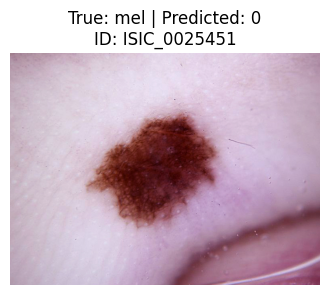

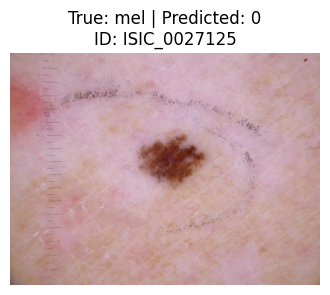

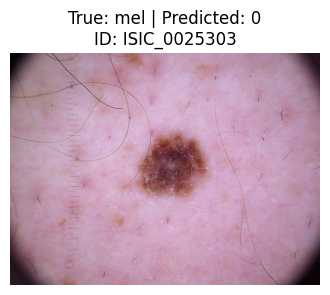

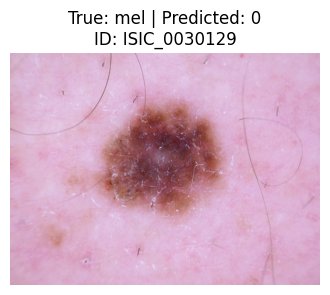

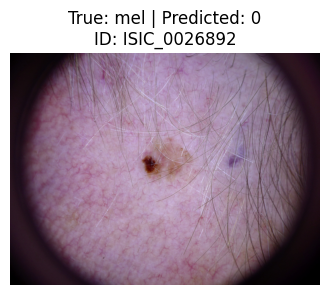

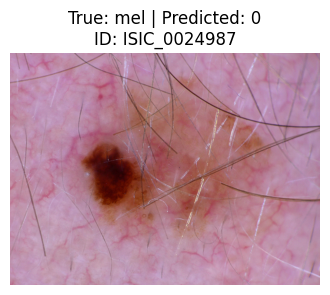

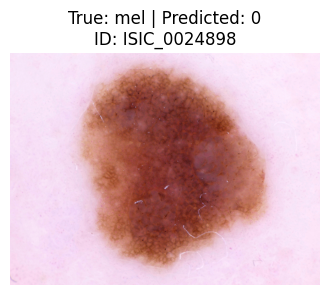

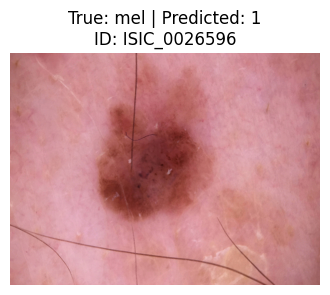

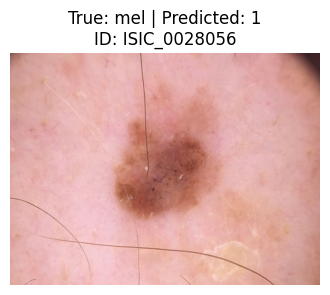

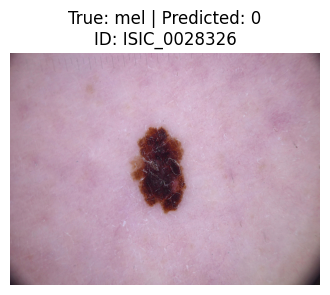

In [134]:
import matplotlib.pyplot as plt
from PIL import Image

for _, row in missed_mel_samples.head(10).iterrows():

    image_path = IMAGES_DIR / f"{row['image_id']}.jpg"
    image = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(
        f"True: mel | Predicted: "
        f"{experiment2_all_predictions[row.name]}"
        f"\nID: {row['image_id']}"
    )
    plt.axis("off")
    plt.show()

check confidence score

In [152]:
import torch

experiment2_model.eval()

experiment2_all_labels = []
experiment2_all_predictions = []
experiment2_all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        output = experiment2_model(images)

        probabilities = torch.softmax(output, dim=1)
        predictions = torch.argmax(output, dim=1)

        experiment2_all_labels.extend(
            labels.cpu().numpy()
        )

        experiment2_all_predictions.extend(
            predictions.cpu().numpy()
        )

        experiment2_all_probs.extend(
            probabilities.cpu().numpy()
        )

In [153]:
import numpy as np

experiment2_all_probs = np.array(experiment2_all_probs)

print(experiment2_all_probs.shape)

(1532, 7)


In [154]:
mel_to_nv_indices = [
    i
    for i in range(len(experiment2_all_labels))
    if experiment2_all_labels[i] == 2
    and experiment2_all_predictions[i] == 0
]

mel_to_nv_probs = experiment2_all_probs[mel_to_nv_indices]

print("Number of mel → nv errors:", len(mel_to_nv_indices))
print(mel_to_nv_probs[:, [0, 2]][:10])

Number of mel → nv errors: 34
[[0.17605542 0.15593967]
 [0.18123989 0.1716395 ]
 [0.18522534 0.17474647]
 [0.18353198 0.16689512]
 [0.16620888 0.14399917]
 [0.19556881 0.16091369]
 [0.18935567 0.18204892]
 [0.17251521 0.1493242 ]
 [0.19226679 0.18379733]
 [0.16742665 0.13927612]]


In [155]:
mel_to_nv_probs = experiment2_all_probs[mel_to_nv_indices]

p_nv = mel_to_nv_probs[:, 0]
p_mel = mel_to_nv_probs[:, 2]

print("Mean P(NV):", p_nv.mean())
print("Median P(NV):", np.median(p_nv))

print("Mean P(MEL):", p_mel.mean())
print("Median P(MEL):", np.median(p_mel))

print("\nHigh-confidence NV predictions:")
print("P(NV) > 0.80:", np.sum(p_nv > 0.80))
print("P(NV) > 0.90:", np.sum(p_nv > 0.90))
print("P(NV) > 0.95:", np.sum(p_nv > 0.95))

print("\nAmbiguous predictions:")
print("P(NV) between 0.4 and 0.6:",
      np.sum((p_nv >= 0.4) & (p_nv <= 0.6)))

Mean P(NV): 0.18436658
Median P(NV): 0.18242803
Mean P(MEL): 0.16300832
Median P(MEL): 0.16707

High-confidence NV predictions:
P(NV) > 0.80: 0
P(NV) > 0.90: 0
P(NV) > 0.95: 0

Ambiguous predictions:
P(NV) between 0.4 and 0.6: 0


In [156]:
class_counts = train_meta["dx"].value_counts().sort_index()

print(class_counts)

dx
akiec     230
bcc       366
bkl       774
df         76
mel       778
nv       4679
vasc       99
Name: count, dtype: int64


Investigating if general class balancing improves the minority-class performance.

In [157]:
class_order = ["nv", "bkl", "mel", "bcc", "akiec", "vasc", "df"]

counts = train_meta["dx"].value_counts().reindex(class_order)

weights = 1.0 / np.sqrt(counts.values.astype(np.float32))

# Normalize so average weight = 1
weights = weights / weights.mean()

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

print("Class counts:")
print(counts)

print("\nClass weights:")
for cls, count, weight in zip(class_order, counts, weights):
    print(f"{cls:5s} | count={count:4d} | weight={weight:.3f}")

Class counts:
dx
nv       4679
bkl       774
mel       778
bcc       366
akiec     230
vasc       99
df         76
Name: count, dtype: int64

Class weights:
nv    | count=4679 | weight=0.244
bkl   | count= 774 | weight=0.599
mel   | count= 778 | weight=0.598
bcc   | count= 366 | weight=0.872
akiec | count= 230 | weight=1.099
vasc  | count=  99 | weight=1.676
df    | count=  76 | weight=1.913


In [158]:
#weighted cross entropy
experiment3_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [159]:
experiment3_model = models.resnet50(weights="IMAGENET1K_V2")

experiment3_model.fc = nn.Linear(
    experiment3_model.fc.in_features,
    7
)

experiment3_model = experiment3_model.to(device)

experiment3_optimizer = torch.optim.AdamW(
    experiment3_model.parameters(),
    lr=1e-4
)

In [160]:
"""experiment3_train_loss_history = []

num_epochs = 5

for epoch in range(num_epochs):
    experiment3_model.train()

    running_loss = 0.0

    for images, labels in experiment2_train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        experiment3_optimizer.zero_grad()

        outputs = experiment3_model(images)

        loss = experiment3_criterion(outputs, labels)

        loss.backward()

        experiment3_optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(experiment2_train_loader.dataset)

    experiment3_train_loss_history.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_loss:.4f}"
    )"""

'experiment3_train_loss_history = []\n\nnum_epochs = 5\n\nfor epoch in range(num_epochs):\n    experiment3_model.train()\n\n    running_loss = 0.0\n\n    for images, labels in experiment2_train_loader:\n        images = images.to(device, non_blocking=True)\n        labels = labels.to(device, non_blocking=True)\n\n        experiment3_optimizer.zero_grad()\n\n        outputs = experiment3_model(images)\n\n        loss = experiment3_criterion(outputs, labels)\n\n        loss.backward()\n\n        experiment3_optimizer.step()\n\n        running_loss += loss.item() * images.size(0)\n\n    epoch_loss = running_loss / len(experiment2_train_loader.dataset)\n\n    experiment3_train_loss_history.append(epoch_loss)\n\n    print(\n        f"Epoch [{epoch+1}/{num_epochs}] "\n        f"Train Loss: {epoch_loss:.4f}"\n    )'

In [161]:
"""experiment3_checkpoint_path = (
    "/content/drive/MyDrive/dermai-ham10000/"
    "resnet50_ham10000_experiment3_weighted_ce.pth"
)

torch.save({
    "epoch": num_epochs,
    "model_state_dict": experiment3_model.state_dict(),
    "optimizer_state_dict": experiment3_optimizer.state_dict(),
    "train_loss_history": experiment3_train_loss_history,
}, experiment3_checkpoint_path)

print(f"Checkpoint saved to: {experiment3_checkpoint_path}")"""

'experiment3_checkpoint_path = (\n    "/content/drive/MyDrive/dermai-ham10000/"\n    "resnet50_ham10000_experiment3_weighted_ce.pth"\n)\n\ntorch.save({\n    "epoch": num_epochs,\n    "model_state_dict": experiment3_model.state_dict(),\n    "optimizer_state_dict": experiment3_optimizer.state_dict(),\n    "train_loss_history": experiment3_train_loss_history,\n}, experiment3_checkpoint_path)\n\nprint(f"Checkpoint saved to: {experiment3_checkpoint_path}")'

In [162]:
"""experiment3_model.eval()

experiment3_all_labels = []
experiment3_all_predictions = []

running_val_loss = 0.0
total_samples = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = experiment3_model(images)

        loss = experiment3_criterion(outputs, labels)

        predictions = outputs.argmax(dim=1)

        batch_size = images.size(0)

        running_val_loss += loss.item() * batch_size
        total_samples += batch_size

        experiment3_all_labels.extend(labels.cpu().numpy())
        experiment3_all_predictions.extend(predictions.cpu().numpy())

experiment3_val_loss = running_val_loss / total_samples

experiment3_accuracy = (
    np.array(experiment3_all_labels)
    == np.array(experiment3_all_predictions)
).mean()

experiment3_macro_f1 = f1_score(
    experiment3_all_labels,
    experiment3_all_predictions,
    average="macro"
)

print(f"Validation Loss: {experiment3_val_loss:.4f}")
print(f"Accuracy: {experiment3_accuracy:.4f}")
print(f"Macro F1: {experiment3_macro_f1:.4f}")"""

'experiment3_model.eval()\n\nexperiment3_all_labels = []\nexperiment3_all_predictions = []\n\nrunning_val_loss = 0.0\ntotal_samples = 0\n\nwith torch.no_grad():\n    for images, labels in val_loader:\n        images = images.to(device, non_blocking=True)\n        labels = labels.to(device, non_blocking=True)\n\n        outputs = experiment3_model(images)\n\n        loss = experiment3_criterion(outputs, labels)\n\n        predictions = outputs.argmax(dim=1)\n\n        batch_size = images.size(0)\n\n        running_val_loss += loss.item() * batch_size\n        total_samples += batch_size\n\n        experiment3_all_labels.extend(labels.cpu().numpy())\n        experiment3_all_predictions.extend(predictions.cpu().numpy())\n\nexperiment3_val_loss = running_val_loss / total_samples\n\nexperiment3_accuracy = (\n    np.array(experiment3_all_labels)\n    == np.array(experiment3_all_predictions)\n).mean()\n\nexperiment3_macro_f1 = f1_score(\n    experiment3_all_labels,\n    experiment3_all_predic

In [163]:
"""experiment3_validation_results = {
    "image_ids": val_meta["image_id"].tolist(),
    "all_labels": experiment3_all_labels,
    "all_predictions": experiment3_all_predictions,
    "accuracy": experiment3_accuracy,
    "val_loss": experiment3_val_loss,
    "macro_f1": experiment3_macro_f1,
}

experiment3_validation_path = (
    "/content/drive/MyDrive/dermai-ham10000/"
    "resnet50_ham10000_experiment3_weighted_ce_validation.pth"
)

torch.save(
    experiment3_validation_results,
    experiment3_validation_path
)

print(f"Validation results saved to: {experiment3_validation_path}")"""

'experiment3_validation_results = {\n    "image_ids": val_meta["image_id"].tolist(),\n    "all_labels": experiment3_all_labels,\n    "all_predictions": experiment3_all_predictions,\n    "accuracy": experiment3_accuracy,\n    "val_loss": experiment3_val_loss,\n    "macro_f1": experiment3_macro_f1,\n}\n\nexperiment3_validation_path = (\n    "/content/drive/MyDrive/dermai-ham10000/"\n    "resnet50_ham10000_experiment3_weighted_ce_validation.pth"\n)\n\ntorch.save(\n    experiment3_validation_results,\n    experiment3_validation_path\n)\n\nprint(f"Validation results saved to: {experiment3_validation_path}")'

In [164]:
experiment3_validation_path = (
    "/content/drive/MyDrive/dermai-ham10000/"
    "resnet50_ham10000_experiment3_weighted_ce_validation.pth"
)

experiment3_validation_results = torch.load(
    experiment3_validation_path,
    map_location="cpu",
    weights_only=False
)

print(experiment3_validation_results.keys())

experiment3_image_ids = experiment3_validation_results["image_ids"]
experiment3_all_labels = experiment3_validation_results["all_labels"]
experiment3_all_predictions = experiment3_validation_results["all_predictions"]
experiment3_accuracy = experiment3_validation_results["accuracy"]
experiment3_val_loss = experiment3_validation_results["val_loss"]
experiment3_macro_f1 = experiment3_validation_results["macro_f1"]

dict_keys(['image_ids', 'all_labels', 'all_predictions', 'accuracy', 'val_loss', 'macro_f1'])


In [165]:
print(classification_report(
    experiment3_all_labels,
    experiment3_all_predictions,
    target_names=class_order,
    digits=3
))

cm_experiment3 = confusion_matrix(
    experiment3_all_labels,
    experiment3_all_predictions
)

print(cm_experiment3)

              precision    recall  f1-score   support

          nv      0.923     0.873     0.898      1034
         bkl      0.632     0.611     0.621       157
         mel      0.433     0.606     0.505       170
         bcc      0.848     0.506     0.634        77
       akiec      0.457     0.725     0.561        51
        vasc      0.833     0.833     0.833        24
          df      0.385     0.263     0.312        19

    accuracy                          0.785      1532
   macro avg      0.644     0.631     0.623      1532
weighted avg      0.812     0.785     0.793      1532

[[903  25  94   3   7   1   1]
 [ 20  96  25   1  15   0   0]
 [ 42  16 103   0   9   0   0]
 [  3   8   7  39  11   3   6]
 [  3   3   4   3  37   0   1]
 [  2   0   2   0   0  20   0]
 [  5   4   3   0   2   0   5]]


Experiment 2 is our current best: 81.85% accuracy, 0.674 macro-F1.

In [167]:
experiment2_checkpoint = torch.load(
    f"{PROJECT_PATH}/resnet50_ham10000_experiment2_no_sampler.pth",
    map_location=device,
    weights_only=False
)

In [168]:
experiment2_model = models.resnet50(weights=None)

experiment2_model.fc = nn.Linear(
    experiment2_model.fc.in_features,
    7
)

experiment2_model = experiment2_model.to(device)

In [169]:
experiment2_model.load_state_dict(
    experiment2_checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [170]:
print("Loaded epoch:", experiment2_checkpoint["epoch"])
print("Training loss history:", experiment2_checkpoint["train_loss_history"])

Loaded epoch: 5
Training loss history: [0.47776903919705516, 0.37492946878960143, 0.29259605021917656, 0.250857858148884, 0.20857786763136246]


In [171]:
experiment2_criterion = nn.CrossEntropyLoss()

In [185]:
"""experiment2_model.eval()

test_all_labels = []
test_all_predictions = []

running_test_loss = 0.0
total_samples = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = experiment2_model(images)

        loss = experiment2_criterion(outputs, labels)

        predictions = outputs.argmax(dim=1)

        batch_size = images.size(0)

        running_test_loss += loss.item() * batch_size
        total_samples += batch_size

        test_all_labels.extend(labels.cpu().numpy())
        test_all_predictions.extend(predictions.cpu().numpy())

test_loss = running_test_loss / total_samples

test_accuracy = (
    np.array(test_all_labels) ==
    np.array(test_all_predictions)
).mean()

test_macro_f1 = f1_score(
    test_all_labels,
    test_all_predictions,
    average="macro"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")"""

'experiment2_model.eval()\n\ntest_all_labels = []\ntest_all_predictions = []\n\nrunning_test_loss = 0.0\ntotal_samples = 0\n\nwith torch.no_grad():\n\n    for images, labels in test_loader:\n\n        images = images.to(device, non_blocking=True)\n        labels = labels.to(device, non_blocking=True)\n\n        outputs = experiment2_model(images)\n\n        loss = experiment2_criterion(outputs, labels)\n\n        predictions = outputs.argmax(dim=1)\n\n        batch_size = images.size(0)\n\n        running_test_loss += loss.item() * batch_size\n        total_samples += batch_size\n\n        test_all_labels.extend(labels.cpu().numpy())\n        test_all_predictions.extend(predictions.cpu().numpy())\n\ntest_loss = running_test_loss / total_samples\n\ntest_accuracy = (\n    np.array(test_all_labels) ==\n    np.array(test_all_predictions)\n).mean()\n\ntest_macro_f1 = f1_score(\n    test_all_labels,\n    test_all_predictions,\n    average="macro"\n)\n\nprint(f"Test Loss: {test_loss:.4f}")\np

In [173]:
corrupt_image_id = "ISIC_0026915"

print(
    test_meta[
        test_meta["image_id"] == corrupt_image_id
    ]
)

       lesion_id      image_id  dx    dx_type   age     sex     localization  \
557  HAM_0002851  ISIC_0026915  nv  follow_up  55.0  female  lower extremity   

                                            image_path  label  
557  /content/drive/MyDrive/dermai-ham10000/data/im...      0  


In [174]:
test_meta_clean = test_meta[
    test_meta["image_id"] != "ISIC_0026915"
].reset_index(drop=True)

print("Original test size:", len(test_meta))
print("Clean test size:", len(test_meta_clean))
print("Removed:", len(test_meta) - len(test_meta_clean))

Original test size: 1481
Clean test size: 1480
Removed: 1


In [179]:
test_meta_clean = test_meta[
    test_meta["image_id"] != "ISIC_0026915"
].reset_index(drop=True)

test_dataset_clean = SkinLesionClassifier(
    test_meta_clean,
    transform=test_transform
)

test_loader_clean = DataLoader(
    test_dataset_clean,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [181]:
from sklearn.metrics import f1_score
experiment2_model.eval()

test_all_labels = []
test_all_predictions = []

running_test_loss = 0.0
total_samples = 0

with torch.no_grad():

    for images, labels in test_loader_clean:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = experiment2_model(images)

        loss = experiment2_criterion(outputs, labels)

        predictions = outputs.argmax(dim=1)

        batch_size = images.size(0)

        running_test_loss += loss.item() * batch_size
        total_samples += batch_size

        test_all_labels.extend(labels.cpu().numpy())
        test_all_predictions.extend(predictions.cpu().numpy())

test_loss = running_test_loss / total_samples

test_accuracy = (
    np.array(test_all_labels) ==
    np.array(test_all_predictions)
).mean()

test_macro_f1 = f1_score(
    test_all_labels,
    test_all_predictions,
    average="macro"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")

Test Loss: 0.5374
Test Accuracy: 0.8223
Test Macro F1: 0.6657


In [184]:
final_test_results = {
    "image_ids": test_meta_clean["image_id"].tolist(),
    "test_all_labels": test_all_labels,
    "test_all_predictions": test_all_predictions,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "test_macro_f1": test_macro_f1,
    "excluded_images": ["ISIC_0026915"],
}

test_results_path = (
    f"{PROJECT_PATH}/"
    "resnet50_ham10000_experiment2_final_test_results.pth"
)

torch.save(
    final_test_results,
    test_results_path
)

print(f"✅ Final test results saved to:\n{test_results_path}")

✅ Final test results saved to:
/content/drive/MyDrive/dermai-ham10000/resnet50_ham10000_experiment2_final_test_results.pth


In [186]:
test_results_path = (
    f"{PROJECT_PATH}/"
    "resnet50_ham10000_experiment2_final_test_results.pth"
)

final_test_results = torch.load(
    test_results_path,
    weights_only=False
)

# Restore all variables
test_image_ids = final_test_results["image_ids"]

test_all_labels = final_test_results["test_all_labels"]
test_all_predictions = final_test_results["test_all_predictions"]

test_accuracy = final_test_results["test_accuracy"]
test_loss = final_test_results["test_loss"]
test_macro_f1 = final_test_results["test_macro_f1"]

excluded_images = final_test_results["excluded_images"]

In [182]:
print(classification_report(
    test_all_labels,
    test_all_predictions,
    target_names=class_order,
    digits=3
))

              precision    recall  f1-score   support

          nv      0.935     0.907     0.921       991
         bkl      0.674     0.702     0.688       168
         mel      0.588     0.570     0.578       165
         bcc      0.679     0.746     0.711        71
       akiec      0.453     0.630     0.527        46
        vasc      0.882     0.789     0.833        19
          df      0.360     0.450     0.400        20

    accuracy                          0.822      1480
   macro avg      0.653     0.685     0.666      1480
weighted avg      0.831     0.822     0.826      1480



In [183]:
cm_test = confusion_matrix(
    test_all_labels,
    test_all_predictions
)

print(cm_test)

[[899  28  47   9   3   0   5]
 [ 14 118  16   2   8   1   9]
 [ 37  17  94   2  15   0   0]
 [  6   6   0  53   5   1   0]
 [  2   5   1   7  29   0   2]
 [  2   0   0   2   0  15   0]
 [  1   1   2   3   4   0   9]]
